# 05 Ubalanserte data, ROC/PR-kurver og valg av terskel
*Data Mining & Analytics – Samling 2, dag 2*

In [10]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"    

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42)

In [11]:
from sklearn.metrics import confusion_matrix

def klassifiserings_metrikker(y_sann, y_pred):
    """Metrikker for binær klassifisering (positiv klasse = 1)."""
    tn, fp, fn, tp = confusion_matrix(y_sann, y_pred, labels=[0, 1]).ravel()
    return {"nøyaktighet": (tp + tn) / (tp + tn + fp + fn),
            "sensitivitet": tp / (tp + fn) if tp + fn else np.nan,
            "spesifisitet": tn / (tn + fp) if tn + fp else np.nan,
            "presisjon": tp / (tp + fp) if tp + fp else np.nan,
            "F1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else np.nan}

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

# Syntetisk datasett: 2 % positive
X, y = make_classification(n_samples=20_000, n_features=12, n_informative=6, n_redundant=2,
                           weights=[0.98], class_sep=0.9, flip_y=0.005, random_state=0)
print("Andel positive:", y.mean().round(3))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

Andel positive: 0.023


## Nøyaktighetsfella
En modell som alltid sier «ikke positiv» har ca. 98 % nøyaktighet…

In [13]:
dum = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print({k: round(v, 3) for k, v in klassifiserings_metrikker(y_test, dum.predict(X_test)).items()})

{'nøyaktighet': np.float64(0.977), 'sensitivitet': np.float64(0.0), 'spesifisitet': np.float64(1.0), 'presisjon': nan, 'F1': np.float64(0.0)}


men sensitiviteten er 0: den finner ingen svindlere. Nøyaktighet er misvisende ved ubalanserte klasser.

## Strategier ved ubalanserte data
* Klassevekter: (class_weight="balanced): feil på den underrepresenterte klassen straffes hardere
* Undersampling: fjerne data fra den best/høyest representerte klassen 
* Oversampling / SMOTE: lager syntetiske eksempler av den underrepresenterte klassen ved hjelp av interpolering


In [18]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

modeller = {
    "Standard": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "class_weight=balanced": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")),
    "SMOTE": ImbPipeline([("sc", StandardScaler()), ("smote", SMOTE(random_state=0)), ("lr", LogisticRegression(max_iter=2000))]),
    "Undersampling": ImbPipeline([("sc", StandardScaler()), ("us", RandomUnderSampler(random_state=0)), ("lr", LogisticRegression(max_iter=2000))]),
}
probs, my_list = {}, []
for navn, modell in modeller.items():
    modell.fit(X_train, y_train)
    pred = modell.predict_proba(X_test)[:, 1]; probs[navn] = pred
    r = klassifiserings_metrikker(y_test, (pred >= 0.5).astype(int))
    r.update({"AUROC": roc_auc_score(y_test, pred), "AUPRC": average_precision_score(y_test, pred)})
    my_list.append(pd.Series(r, name=navn))
print(pd.DataFrame(my_list).round(3))

                       nøyaktighet  sensitivitet  spesifisitet  presisjon  \
Standard                     0.977         0.101         0.998      0.538   
class_weight=balanced        0.824         0.783         0.825      0.095   
SMOTE                        0.832         0.775         0.834      0.099   
Undersampling                0.841         0.790         0.842      0.105   

                          F1  AUROC  AUPRC  
Standard               0.171  0.856  0.298  
class_weight=balanced  0.170  0.867  0.224  
SMOTE                  0.176  0.867  0.231  
Undersampling          0.186  0.865  0.218  


c:\Users\bjsin\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\bjsin\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\bjsin\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\bjsin\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


## ROC- og PR-kurver

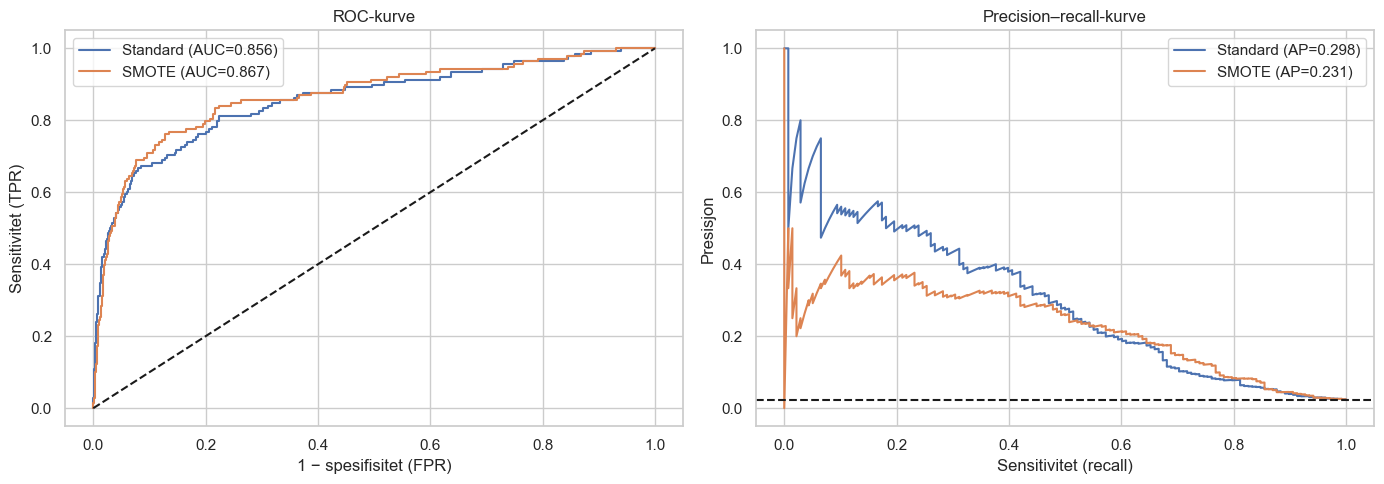

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for navn in ["Standard", "SMOTE"]:
    fpr, tpr, _ = roc_curve(y_test, probs[navn])
    ax[0].plot(fpr, tpr, label=f"{navn} (AUC={roc_auc_score(y_test, probs[navn]):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, probs[navn]) 
    ax[1].plot(rc, pr, label=f"{navn} (AP={average_precision_score(y_test, probs[navn]):.3f})")
ax[0].plot([0, 1], [0, 1], "k--")
ax[0].set_xlabel("1 − spesifisitet (FPR)")
ax[0].set_ylabel("Sensitivitet (TPR)")
ax[0].set_title("ROC-kurve")
ax[0].legend()

ax[1].axhline(y_test.mean(), color="k", ls="--")
ax[1].set_xlabel("Sensitivitet (recall)")
ax[1].set_ylabel("Presisjon")
ax[1].set_title("Precision–recall-kurve")
ax[1].legend()

plt.tight_layout()
plt.show()

## Velge terskel

Regel: velg terskelen på treningsdata og evaluer den på testdata.

Scenario: kravet for sensitivitet ≥ 90 %. Hva er terskelen, og hvordan påvirker det presisjon?

In [ ]:
modell = modeller["Standard"]
oof = cross_val_predict(modell, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]
fpr, tpr, terskler = roc_curve(y_train, oof)

t_krav = terskler[np.argmax(tpr >= 0.90)]              # høyeste terskel som gir sensitivitet >= 0.90
t_youden = terskler[np.argmax(tpr - fpr)]              # Youdens J = sens + spes - 1
kost_fn, kost_fp = 20, 1                               # anta at en oversett positiv klasse koster 20x en falsk alarm
kostnad = [(kost_fn * ((oof < t) & (y_train == 1)).sum() + kost_fp * ((oof >= t) & (y_train == 0)).sum()) for t in terskler]
t_kost = terskler[int(np.argmin(kostnad))]

modell.fit(X_train, y_train)
p = modell.predict_proba(X_test)[:, 1]
rader = {}
for navn, t in [("Standard 0.5", 0.5), ("Krav: sens ≥ 0.90", t_krav), ("Youden J", t_youden), ("Kostnadsminimering (20:1)", t_kost)]:
    rader[navn] = {"terskel": t, **klassifiserings_metrikker(y_test, (p >= t).astype(int))}
print(pd.DataFrame(rader).T.round(3))

                           terskel  nøyaktighet  sensitivitet  spesifisitet  \
Standard 0.5                 0.500        0.977         0.101         0.998   
Krav: sens ≥ 0.90            0.007        0.531         0.891         0.522   
Youden J                     0.039        0.884         0.681         0.889   
Kostnadsminimering (20:1)    0.065        0.930         0.609         0.937   

                           presisjon     F1  
Standard 0.5                   0.538  0.171  
Krav: sens ≥ 0.90              0.042  0.080  
Youden J                       0.126  0.213  
Kostnadsminimering (20:1)      0.186  0.285  


## Kalibrering

Betyr «0.7 i prediksjon at 70 % av tilfellene (som får 0.7 i prediksjonsskår) faktisk er positive? 

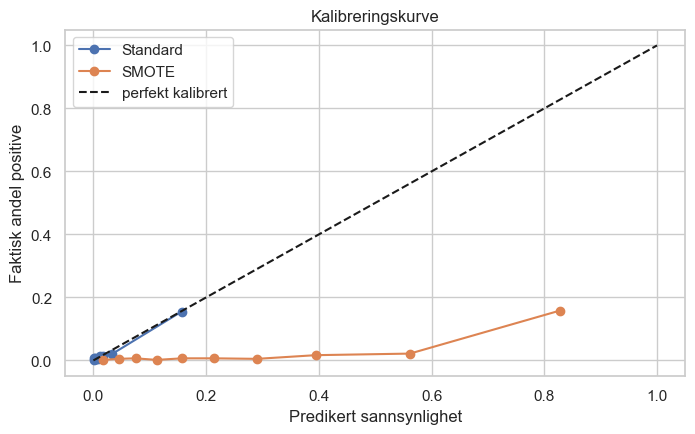

In [19]:
from sklearn.calibration import calibration_curve
for navn in ["Standard", "SMOTE"]:
    frac, snitt = calibration_curve(y_test, probs[navn], n_bins=10, strategy="quantile")
    plt.plot(snitt, frac, "o-", label=navn)
plt.plot([0, 1], [0, 1], "k--", label="perfekt kalibrert")
plt.xlabel("Predikert sannsynlighet")
plt.ylabel("Faktisk andel positive")
plt.legend()
plt.title("Kalibreringskurve")
plt.show()